<a href="https://colab.research.google.com/github/ZiqiLi379/STATS-302-Intro-to-ML/blob/main/STATS302_Week_4_Fitting_Regression_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Week 4 - Fitting Regression Trees
###STATS 302 Principle of Machine Learning
###Duke Kunshan University

In [1]:
import pandas as pd
import numpy as np

# from sklearn.datasets import load_boston
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn import tree

import graphviz

import matplotlib.pyplot as plt

# from google.colab import files
# import io

In [1]:
import sys
print(sys.executable)

D:\anaconda3\python.exe


In [2]:
# loading the dataset
boston = pd.read_csv(r"D:\UG Files\Year 4\S3\STATS 302\Codes\STATS-302-Intro-to-ML\Week_2\Week_2_Data\boston.csv")
boston = boston.drop(boston.columns[0], axis=1)
print(boston.shape)
boston.head()

# boston_data = load_boston()
# boston = pd.DataFrame(boston_data.data,columns = boston_data['feature_names'])
# boston['MEDV'] = boston_data['target']
# boston.head()

(506, 13)


,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


Get famlier with the data:
- CRIM - per capita crime rate by town
- ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
- INDUS - proportion of non-retail business acres per town.
- CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
- NOX - nitric oxides concentration (parts per 10 million)
- RM - average number of rooms per dwelling
- AGE - proportion of owner-occupied units built prior to 1940
- DIS - weighted distances to five Boston employment centres
- RAD - index of accessibility to radial highways
- TAX - full-value property-tax rate per $10,000

- PTRATIO - pupil-teacher ratio by town
- B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
- LSTAT - % lower status of the population
- MEDV - Median value of owner-occupied homes in $1000's

soucrs - [https://www.cs.toronto.edu/~delve/data/boston/bostonDetail.html]

Its better that we go through the above list once, so that we know what we are dealing with here.

In [3]:
#splitting the data into train and test
X_train,X_test,y_train,y_test = train_test_split(boston.drop('MEDV',axis = 1),boston['MEDV'],test_size = 0.7,random_state = 0)

In [4]:
reg = DecisionTreeRegressor()
reg.fit(X_train,y_train)
print('Training score ',reg.score(X_train,y_train))
print('Test scire ',reg.score(X_test,y_test))

Training score  1.0
Test scire  0.5731696325291447


In [5]:
# from the above results, it looks like the tree is overfitting, we will set a max_depth parameter
reg = DecisionTreeRegressor(max_depth = 5)
reg.fit(X_train,y_train)
print('Training score ',reg.score(X_train,y_train))
print('Test scire ',reg.score(X_test,y_test))

Training score  0.9678973812322104
Test scire  0.6615814762656045


Let's try what we can get if max_depth = 7

In [6]:
depth7 = DecisionTreeRegressor(max_depth=7)

# lets see its performance on unseen data
depth7.fit(X_train,y_train)
print('Training score ',depth7.score(X_train,y_train))
print('Test scpre ',depth7.score(X_test,y_test))

Training score  0.9904484327224299
Test scpre  0.5845321674845145


We can see that we are getting lower test score for tree with max_depth = 7, than for a tree with max depth = 5.
So we will use max_depth = 7 to visualize our tree.

## Visualing the graph

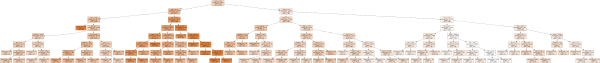

In [17]:
dot_data = tree.export_graphviz(depth7, out_file=None,
                                feature_names=X_train.columns,
                                filled=True)

# Draw graph
dot_data = dot_data.replace(
    "digraph Tree {",
    'digraph Tree {\nsize="2,5";\ndpi=300;'
)
graph = graphviz.Source(dot_data, format="png")
graph